In [1]:
# 1. Drive 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/sunwoo604/CSCI566_project.git
%cd CSCI566_project/preprocessing
!ls

Cloning into 'CSCI566_project'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 15 (delta 1), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 73.41 KiB | 14.68 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/CSCI566_project/preprocessing
image_processing.py  unpack.py


In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.metrics import cohen_kappa_score

from unpack import unpack_data, unpack_label, image_to_score
from image_processing import resize_images, apply_clahe, normalize_images

In [4]:
raw_dir = "/Users/hannah/Downloads/diabetic-retinopathy-detection/train"
normalized_dir = "/content/drive/MyDrive/Colab Notebooks/CSCI566/eyepacs/normalized_5000"
# resized_dir = resize_images(input_dir=raw_dir, size=(224,224), output_dir="/Users/hannah/Downloads/diabetic-retinopathy-detection/resized_5000")
# clahe_dir = apply_clahe(input_dir=resized_dir, output_dir="/Users/사용자이름/Desktop/clahe_5000")
# normalized_dir = normalize_images(input_dir=clahe_dir, output_dir="/Users/사용자이름/Desktop/normalized_5000")

In [5]:
import torchvision.transforms as transforms

class DRDataset(Dataset):
    def __init__(self, data_dir, label_dict, files=None, augment=False):
        self.data_dir = data_dir
        self.label_dict = label_dict
        self.augment = augment
        if files is not None:
            self.files = files
        else:
            self.files = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        img = np.load(os.path.join(self.data_dir, file_name))  # (H,W,3)
        img = torch.tensor(img).permute(2,0,1).float()  # (3,H,W)

        if self.augment:
          # if np.random.rand() > 0.5:
            transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                # transforms.RandomRotation(15),
                # transforms.ColorJitter(brightness=0.2, contrast=0.2), # 밝기/대비 변화 추가
            ])
            img = transform(img)

        label = int(self.label_dict[file_name.replace(".npy","")])
        return img, label

In [6]:
from sklearn.model_selection import train_test_split

label_dict = image_to_score("/content/drive/MyDrive/Colab Notebooks/CSCI566/eyepacs/trainLabels.csv")

# 전체 dataset (files 리스트 뽑기용)
dataset = DRDataset(normalized_dir, label_dict)
files = dataset.files
labels_list = [label_dict[f.replace(".npy", "")] for f in files]

# stratified split (70/15/15)
train_files, temp_files, train_labels, temp_labels = train_test_split(
    files, labels_list, test_size=0.3, stratify=labels_list, random_state=42
)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

# 각각 Dataset 생성
train_dataset = DRDataset(normalized_dir, label_dict, files=train_files, augment=True)
val_dataset = DRDataset(normalized_dir, label_dict, files=val_files, augment=False)
test_dataset = DRDataset(normalized_dir, label_dict, files=test_files, augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
# 마지막 layer 수정 (5 classes)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.0),
    nn.Linear(num_ftrs, 5)
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 94.0MB/s]


In [8]:
# partial fine-tuning
# for name, param in model.named_parameters():
#     if "layer4" in name or "fc" in name:
#         param.requires_grad = True
#     else:
#         param.requires_grad = False

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [9]:
# class weight 계산

from collections import Counter
labels_list = [label_dict[f.replace(".npy", "")] for f in dataset.files]
class_counts = Counter(labels_list)
print("클래스별 샘플 수:", class_counts)
total = sum(class_counts.values())
class_weights = torch.tensor([
    total / class_counts[str(i)] for i in range(5)
], dtype=torch.float32).to(device)

클래스별 샘플 수: Counter({'0': 3674, '2': 736, '1': 344, '3': 143, '4': 103})


In [10]:
# loss + optimizer

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [12]:
from tqdm import tqdm
num_epochs = 50
best_val_loss = float('inf')
best_qwk = -1.0
patience = 15
counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", position=0, leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()
    model.eval()
    # 매 에폭마다 초기화 필수
    val_loss = 0.0
    all_val_preds = []
    all_val_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # QWK 계산을 위한 데이터 수집
            _, predicted = torch.max(outputs, 1)
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    val_qwk = cohen_kappa_score(all_val_labels, all_val_preds, weights='quadratic')
    accuracy = 100 * sum(p == l for p, l in zip(all_val_preds, all_val_labels)) / len(all_val_labels)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Qwk: {val_qwk:.4f}, Val Acc: {accuracy:.2f}%")

    # Early Stopping (val 기준)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Early Stopping (QWK 기준)
    # if val_qwk > best_qwk:
    #     best_qwk = val_qwk
    #     counter = 0
    #     torch.save(model.state_dict(), "best_dr_model.pth")
    #     # print(f"새로운 최고 QWK 달성! 모델 저장 완료: {best_qwk:.4f}")
    # else:
    #     counter += 1
    #     if counter >= patience:
    #         print(f"Early stopping triggered at epoch {epoch+1}")
    #         break

Epoch 1, Train Loss: 1.3590, Val Loss: 1.4245, Val Qwk: 0.2789, Val Acc: 52.00%


Epoch 2, Train Loss: 1.3628, Val Loss: 1.4081, Val Qwk: 0.2803, Val Acc: 44.27%


Epoch 3, Train Loss: 1.3503, Val Loss: 1.4042, Val Qwk: 0.2741, Val Acc: 35.60%


Epoch 4, Train Loss: 1.3367, Val Loss: 1.4023, Val Qwk: 0.2499, Val Acc: 35.60%


Epoch 5, Train Loss: 1.3253, Val Loss: 1.3915, Val Qwk: 0.2973, Val Acc: 41.87%


...

Epoch 45, Train Loss: 1.2652, Val Loss: 1.3630, Val Qwk: 0.2974, Val Acc: 47.87%


Epoch 46, Train Loss: 1.2490, Val Loss: 1.3627, Val Qwk: 0.3050, Val Acc: 48.00%


Epoch 47, Train Loss: 1.2441, Val Loss: 1.3607, Val Qwk: 0.2950, Val Acc: 45.60%


Epoch 48, Train Loss: 1.2468, Val Loss: 1.3624, Val Qwk: 0.2941, Val Acc: 47.87%


Epoch 49, Train Loss: 1.2471, Val Loss: 1.3608, Val Qwk: 0.3006, Val Acc: 48.13%
Early stopping at epoch 49


In [13]:
# 테스트
from sklearn.metrics import cohen_kappa_score, roc_auc_score
import numpy as np

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

test_loss = 0.0
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

accuracy = 100 * (all_preds == all_labels).sum() / len(all_labels)
qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

print(f"Test Loss: {test_loss/len(test_loader):.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"QWK: {qwk:.4f}")
print(f"AUC: {auc:.4f}")

Test Loss: 1.3736
Test Accuracy: 48.67%
QWK: 0.2984
AUC: 0.7038


In [14]:
# 예측 분포 확인
from collections import Counter
pred_counts = Counter(all_preds.tolist())
print("예측 분포:", pred_counts)
print("실제 분포:", Counter(all_labels.tolist()))

예측 분포: Counter({0: 352, 1: 150, 2: 116, 4: 77, 3: 55})
실제 분포: Counter({0: 551, 2: 110, 1: 51, 3: 22, 4: 16})


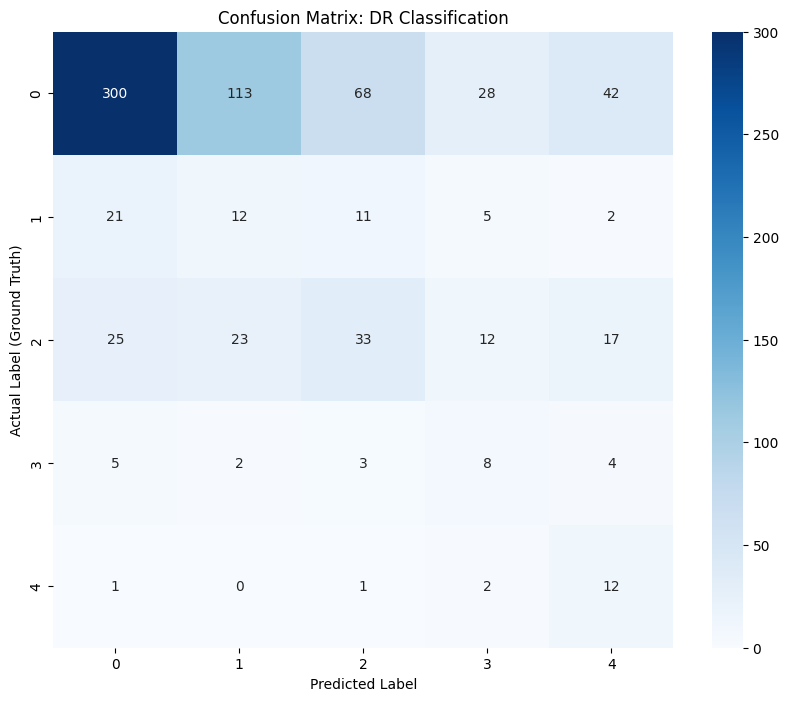

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(all_labels, all_preds, classes):
    # 1. 혼동 행렬 계산
    cm = confusion_matrix(all_labels, all_preds)

    # 2. 시각화 설정
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title('Confusion Matrix: DR Classification')
    plt.ylabel('Actual Label (Ground Truth)')
    plt.xlabel('Predicted Label')
    plt.show()

# 클래스 정의 (0: Normal, 1: Mild, 2: Moderate, 3: Severe, 4: Proliferative)
class_names = ['0', '1', '2', '3', '4']

# 함수 실행 (기존 테스트 코드에서 저장된 all_labels, all_preds 변수 사용)
plot_confusion_matrix(all_labels, all_preds, class_names)